In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import numpy as np
import seaborn as sns
import time
import os
import json
import math

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler

from openai import OpenAI
client = OpenAI()

In [2]:
llm_queue_full = pd.read_parquet("llm_queue_full.parquet")
final_val_db = pd.read_parquet("final_val_db.parquet")
val_df = pd.read_parquet("val_df.parquet")

In [3]:
final_val_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288888 entries, 0 to 288887
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   orig_idx           288888 non-null  int64  
 1   narr_clean         288888 non-null  object 
 2   narr_word_len      288888 non-null  int64  
 3   true_label         288888 non-null  object 
 4   ml_pred            288888 non-null  object 
 5   margin_gap         288888 non-null  float64
 6   use_llm            288888 non-null  bool   
 7   prediction_source  288888 non-null  object 
 8   llm_label          23041 non-null   object 
 9   llm_confidence     23041 non-null   float64
 10  llm_reason         23041 non-null   object 
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 22.3+ MB


In [4]:
print(final_val_db.shape)
print(final_val_db["llm_label"].value_counts())

(288888, 11)
llm_label
Product/Process Failure    7886
Communication Failure      7483
Escalation Failure         6490
Other Failure              1182
Name: count, dtype: int64


In [9]:
threshold = final_val_db["margin_gap"].quantile(0.05)

def get_final_prediction(row):
    if row["margin_gap"] >= threshold:
        return row["ml_pred"]
    else:
        if pd.notnull(row["llm_label"]) and row["llm_confidence"] >= 0.75:
            return row["llm_label"]
        return row["ml_pred"]
        

In [11]:
final_val_db["final_pred"] = final_val_db.apply(
    lambda row: get_final_prediction(row),
    axis=1
)

In [131]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ----------------------------
# 1) Filter disagreement cases
# ----------------------------
# Assumes final_val_db already has:
# true_label, ml_pred, final_pred, narr_clean, margin_gap, llm_label, llm_confidence

changed_df = final_val_db.loc[
    final_val_db["final_pred"] != final_val_db["ml_pred"]
].copy()

print("Rows where hybrid changed ML:", len(changed_df))

# ----------------------------
# 2) Sample 100 for manual audit
# ----------------------------
# Change n=50 if you want a smaller set
# n = min(50, len(changed_df))
# audit_sample = changed_df.sample(n=n, random_state=42).copy()

# # Optional: sort by uncertainty so hardest cases show first
# audit_sample = audit_sample.sort_values("margin_gap", ascending=True).reset_index(drop=True)

# # ----------------------------
# # 3) Add manual review columns
# # ----------------------------
# audit_sample["manual_label"] = ""          # You fill this in manually
# audit_sample["review_notes"] = ""          # Optional notes
# audit_sample["ml_correct_manual"] = ""     # Optional
# audit_sample["hybrid_correct_manual"] = "" # Optional

# # Keep only useful columns
# audit_sheet = audit_sample[
#     [
#         "orig_idx",
#         "narr_clean",
#         "true_label",
#         "ml_pred",
#         "final_pred",
#         "llm_label",
#         "llm_confidence",
#         "margin_gap",
#         "manual_label",
#         "review_notes",
#         "ml_correct_manual",
#         "hybrid_correct_manual",
#     ]
# ].copy()

# # Export for manual review
# audit_path = "hybrid_vs_ml_manual_audit.csv"
# audit_sheet.to_csv(audit_path, index=False)
# print(f"Audit sheet saved to: {audit_path}")


Rows where hybrid changed ML: 9831
Audit sheet saved to: hybrid_vs_ml_manual_audit.csv


In [132]:

# ----------------------------
# 4) AFTER manual labeling:
#    Load completed audit sheet
# ----------------------------
# Replace with your reviewed file name if different
reviewed = pd.read_csv("hybrid_vs_ml_manual_audit_filled.csv")

# # Example usage after you finish labeling:
# reviewed = pd.read_csv("hybrid_vs_ml_manual_audit.csv")

# Clean labels and keep only rows you actually labeled
reviewed["manual_label"] = reviewed["manual_label"].astype(str).str.strip()
reviewed = reviewed[reviewed["manual_label"] != ""].copy()

print("Manually labeled rows:", len(reviewed))

# ----------------------------
# 5) Calculate ML vs Hybrid against manual labels
# ----------------------------
y_true = df["manual_label"]
y_ml = df["ml_pred"]
y_hybrid = df["final_pred"]

print("=== Accuracy (vs Manual Labels) ===")
print("ML Accuracy:", round(accuracy_score(y_true, y_ml), 4))
print("Hybrid Accuracy:", round(accuracy_score(y_true, y_hybrid), 4))
y_true_manual = reviewed["manual_label"]
y_ml = reviewed["ml_pred"]
y_hybrid = reviewed["final_pred"]

print("\n=== Manual Audit Results ===")
print("ML Accuracy:", round(accuracy_score(y_true_manual, y_ml), 4))
print("Hybrid Accuracy:", round(accuracy_score(y_true_manual, y_hybrid), 4))

print("ML Macro F1:", round(f1_score(y_true_manual, y_ml, average="macro"), 4))
print("Hybrid Macro F1:", round(f1_score(y_true_manual, y_hybrid, average="macro"), 4))

print("\n--- ML Classification Report ---")
print(classification_report(y_true_manual, y_ml))

print("\n--- Hybrid Classification Report ---")
print(classification_report(y_true_manual, y_hybrid))

# ----------------------------
# 6) Helpful diagnostics
# ----------------------------
reviewed["ml_correct"] = reviewed["ml_pred"] == reviewed["manual_label"]
reviewed["hybrid_correct"] = reviewed["final_pred"] == reviewed["manual_label"]

fixed_by_hybrid = ((~reviewed["ml_correct"]) & (reviewed["hybrid_correct"])).sum()
hurt_by_hybrid = ((reviewed["ml_correct"]) & (~reviewed["hybrid_correct"])).sum()

print("\nHybrid fixed ML errors:", fixed_by_hybrid)
print("Hybrid hurt correct ML cases:", hurt_by_hybrid)
print("Net gain:", fixed_by_hybrid - hurt_by_hybrid)

Manually labeled rows: 50
=== Accuracy (vs Manual Labels) ===
ML Accuracy: 0.08
Hybrid Accuracy: 0.9

=== Manual Audit Results ===
ML Accuracy: 0.06
Hybrid Accuracy: 0.92
ML Macro F1: 0.0555
Hybrid Macro F1: 0.8632

--- ML Classification Report ---
                         precision    recall  f1-score   support

  Communication Failure       0.00      0.00      0.00        12
     Escalation Failure       0.50      0.04      0.08        23
          Other Failure       0.05      0.25      0.08         4
Product/Process Failure       0.04      0.09      0.06        11

               accuracy                           0.06        50
              macro avg       0.15      0.10      0.06        50
           weighted avg       0.24      0.06      0.06        50


--- Hybrid Classification Report ---
                         precision    recall  f1-score   support

  Communication Failure       0.92      1.00      0.96        12
     Escalation Failure       0.96      0.96      0.96     

In [133]:
from sklearn.metrics import f1_score

print("\n=== Macro F1 (vs Manual Labels) ===")
print("ML Macro F1:", round(f1_score(y_true, y_ml, average="macro"), 4))
print("Hybrid Macro F1:", round(f1_score(y_true, y_hybrid, average="macro"), 4))


=== Macro F1 (vs Manual Labels) ===
ML Macro F1: 0.0605
Hybrid Macro F1: 0.6907


In [134]:
df["ml_correct"] = df["ml_pred"] == df["manual_label"]
df["hybrid_correct"] = df["final_pred"] == df["manual_label"]

fixed = ((~df["ml_correct"]) & (df["hybrid_correct"])).sum()
hurt = ((df["ml_correct"]) & (~df["hybrid_correct"])).sum()

print("\n=== Hybrid Impact ===")
print("Errors fixed by Hybrid:", fixed)
print("Correct ML predictions harmed:", hurt)
print("Net Gain:", fixed - hurt)


=== Hybrid Impact ===
Errors fixed by Hybrid: 45
Correct ML predictions harmed: 4
Net Gain: 41


In [135]:
overall_accuracy = (0.92 * 0.972204) + (0.08 * 0.90)
print(overall_accuracy)

0.96642768


The hybrid model does not increase overall accuracy because the baseline ML model is already optimized to match keyword-based labels, achieving very high performance (97%). The LLM, however, performs semantic interpretation and may assign more contextually appropriate labels that differ from keyword rules. As a result, some correct ML predictions (with respect to keyword labels) are replaced, leading to a slight drop in measured accuracy.

However, the hybrid model is designed to improve performance in low-confidence cases rather than maximize overall accuracy. In these ambiguous scenarios, the ML model performs poorly, while the hybrid model significantly improves alignment with human interpretation. This demonstrates that the hybrid approach adds value where the baseline model is weakest, making it more effective for real-world decision-making despite a small reduction in aggregate accuracy.

In [13]:
# =========================================================
# RISK SCORING FRAMEWORK
# Works even if LLM results exist for only a small sample
# =========================================================

# ---------------------------------------------------------
# A. Build risk features
# ---------------------------------------------------------

# 1. Severity score from final predicted failure type
severity_map = {
    "Escalation Failure": 4,
    "Product/Process Failure": 3,
    "Communication Failure": 2,
    "Other Failure": 1
}

final_val_db["severity_score"] = final_val_db["final_pred"].map(severity_map)

# 2. ML uncertainty from margin gap
# Smaller margin_gap = more ambiguous = higher uncertainty
final_val_db["ml_uncertainty_raw"] = np.log1p(1 / (final_val_db["margin_gap"] + 1e-6))

# 3. LLM uncertainty
# Only 10 rows currently have llm_confidence; for all other rows, fill with 1.0 confidence
# so uncertainty becomes 0 (i.e., no extra LLM-based risk signal yet)
final_val_db["llm_confidence_filled"] = final_val_db["llm_confidence"].fillna(0.9)
final_val_db["llm_uncertainty_raw"] = 1 - final_val_db["llm_confidence_filled"]

# 4. Disagreement signal
# 1 if ML prediction differs from final prediction
# For rows without LLM override, this will usually be 0
final_val_db["disagreement"] = (final_val_db["ml_pred"] != final_val_db["final_pred"]).astype(int)

# 5. LLM reviewed flag
# Helps separate rows that received second-pass review
final_val_db["llm_reviewed"] = final_val_db["llm_confidence"].notna().astype(int)


final_val_db["narr_len_log"] = np.log1p(final_val_db["narr_word_len"])
# ---------------------------------------------------------
# B. Scale numeric risk features to 0-1
# ---------------------------------------------------------

scale_cols = [
    "severity_score",
    "ml_uncertainty_raw",
    "llm_uncertainty_raw",
    "narr_len_log"
]

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(final_val_db[scale_cols])

scaled_col_names = [
    "severity_score_scaled",
    "ml_uncertainty_scaled",
    "llm_uncertainty_scaled",
    "narr_word_len_scaled"
]

final_val_db[scaled_col_names] = scaled_values


# val_df["narr_len_scaled"] = scaler.fit_transform(val_df[["narr_len_log"]])


# ---------------------------------------------------------
# C. Create a derived target for learning risk weights
# ---------------------------------------------------------
# High-risk target is defined as:
# - severe complaint type, OR
# - row flagged for LLM routing, OR
# - disagreement between ML and final prediction
#
# This is a constructed prioritization target, not a true external label.
# It is acceptable for your capstone as a prioritization framework.

# val_df["high_risk_target"] = (
#     val_df["final_pred"].isin(["Escalation Failure", "Product/Process Failure"]) |
#     (val_df["use_llm"] == True) |
#     (val_df["disagreement"] == 1)
# ).astype(int)

final_val_db["high_risk_target"] = (
    (final_val_db["use_llm"] == True) |
    (final_val_db["disagreement"] == 1)
).astype(int)

# Quick sanity check
print("High-risk target distribution:")
print(final_val_db["high_risk_target"].value_counts(normalize=True).round(4))

# ---------------------------------------------------------
# D. Train logistic regression to learn feature weights
# ---------------------------------------------------------

risk_feature_cols = [
    "severity_score_scaled",
    "ml_uncertainty_scaled",
    "llm_uncertainty_scaled",
    "narr_word_len_scaled"
    # "disagreement",
    # "llm_reviewed"
]

X_risk = final_val_db[risk_feature_cols]
y_risk = final_val_db["high_risk_target"]

risk_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

risk_model.fit(X_risk, y_risk)

# ---------------------------------------------------------
# E. Extract learned weights
# ---------------------------------------------------------

weights_df = pd.DataFrame({
    "feature": risk_feature_cols,
    "weight": risk_model.coef_[0]
}).sort_values("weight", ascending=False)

print("\nLearned logistic regression weights:")
print(weights_df)

print("\nIntercept:")
print(risk_model.intercept_[0])

# ---------------------------------------------------------
# F. Final continuous risk score
# ---------------------------------------------------------
# Risk score = probability of being high-risk
final_val_db["risk_score"] = risk_model.predict_proba(X_risk)[:, 1]

print("\nRisk score summary:")
print(final_val_db["risk_score"].describe())

# ---------------------------------------------------------
# G. Convert risk score into High / Medium / Low
# ---------------------------------------------------------
# Use quantile-based cutoffs so you can still produce categories now,
# even before running LLM on the full 27K rows.

medium_cutoff = final_val_db["risk_score"].quantile(0.50)
high_cutoff = final_val_db["risk_score"].quantile(0.80)

def assign_risk_bucket(score):
    if score >= high_cutoff:
        return "High Risk"
    elif score >= medium_cutoff:
        return "Medium Risk"
    else:
        return "Low Risk"

final_val_db["risk_bucket"] = final_val_db["risk_score"].apply(assign_risk_bucket)

print("\nRisk bucket distribution:")
print(final_val_db["risk_bucket"].value_counts())

# ---------------------------------------------------------
# H. Review top risky complaints
# ---------------------------------------------------------

risk_review_cols = [
    "orig_idx",
    "true_label",
    "ml_pred",
    "llm_label",
    "final_pred",
    "margin_gap",
    "llm_confidence",
    "narr_word_len",
    "severity_score",
    "disagreement",
    "use_llm",
    "llm_reviewed",
    "risk_score",
    "risk_bucket"
]

top_risky_cases = final_val_db.sort_values("risk_score", ascending=False)[risk_review_cols].head(20)

print("\nTop 20 risky complaints:")
print(top_risky_cases)



High-risk target distribution:
high_risk_target
0    0.92
1    0.08
Name: proportion, dtype: float64

Learned logistic regression weights:
                  feature      weight
1   ml_uncertainty_scaled  154.369158
2  llm_uncertainty_scaled    3.599794
3    narr_word_len_scaled    1.425520
0   severity_score_scaled    0.369743

Intercept:
-9.863136638991422

Risk score summary:
count    288888.000000
mean          0.127222
std           0.267506
min           0.000129
25%           0.004064
50%           0.012891
75%           0.067802
max           1.000000
Name: risk_score, dtype: float64

Risk bucket distribution:
risk_bucket
Low Risk       144444
Medium Risk     86666
High Risk       57778
Name: count, dtype: int64

Top 20 risky complaints:
        orig_idx               true_label                  ml_pred  \
104851    104851            Other Failure            Other Failure   
186805    186805  Product/Process Failure            Other Failure   
99912      99912            Other F

In [15]:
# =========================================================
# RISK SCORING FRAMEWORK
# Works even if LLM results exist for only a small sample
# =========================================================

# ---------------------------------------------------------
# A. Build risk features
# ---------------------------------------------------------

# 1. Severity score from final predicted failure type
severity_map = {
    "Escalation Failure": 4,
    "Product/Process Failure": 3,
    "Communication Failure": 2,
    "Other Failure": 1
}

final_val_db["severity_score"] = final_val_db["final_pred"].map(severity_map)

# 2. ML uncertainty from margin gap
# Smaller margin_gap = more ambiguous = higher uncertainty
final_val_db["ml_uncertainty_raw"] = np.log1p(1 / (final_val_db["margin_gap"] + 1e-6))

# 3. LLM uncertainty
# Only 10 rows currently have llm_confidence; for all other rows, fill with 1.0 confidence
# so uncertainty becomes 0 (i.e., no extra LLM-based risk signal yet)
final_val_db["llm_confidence_filled"] = final_val_db["llm_confidence"].fillna(0.9)
final_val_db["llm_uncertainty_raw"] = 1 - final_val_db["llm_confidence_filled"]

# 4. Disagreement signal
# 1 if ML prediction differs from final prediction
# For rows without LLM override, this will usually be 0
final_val_db["disagreement"] = (final_val_db["ml_pred"] != final_val_db["final_pred"]).astype(int)

# 5. LLM reviewed flag
# Helps separate rows that received second-pass review
final_val_db["llm_reviewed"] = final_val_db["llm_confidence"].notna().astype(int)


final_val_db["narr_len_log"] = np.log1p(final_val_db["narr_word_len"])
# ---------------------------------------------------------
# B. Scale numeric risk features to 0-1
# ---------------------------------------------------------

scale_cols = [
    "severity_score",
    "ml_uncertainty_raw",
    "llm_uncertainty_raw",
    "narr_len_log"
]

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(final_val_db[scale_cols])

scaled_col_names = [
    "severity_score_scaled",
    "ml_uncertainty_scaled",
    "llm_uncertainty_scaled",
    "narr_word_len_scaled"
]

final_val_db[scaled_col_names] = scaled_values


# val_df["narr_len_scaled"] = scaler.fit_transform(val_df[["narr_len_log"]])


# ---------------------------------------------------------
# C. Create a derived target for learning risk weights
# ---------------------------------------------------------
# High-risk target is defined as:
# - severe complaint type, OR
# - row flagged for LLM routing, OR
# - disagreement between ML and final prediction
#
# This is a constructed prioritization target, not a true external label.
# It is acceptable for your capstone as a prioritization framework.

# val_df["high_risk_target"] = (
#     val_df["final_pred"].isin(["Escalation Failure", "Product/Process Failure"]) |
#     (val_df["use_llm"] == True) |
#     (val_df["disagreement"] == 1)
# ).astype(int)

final_val_db["high_risk_target"] = (
    (final_val_db["use_llm"] == True) |
    (final_val_db["disagreement"] == 1)
).astype(int)

# Quick sanity check
print("High-risk target distribution:")
print(final_val_db["high_risk_target"].value_counts(normalize=True).round(4))

# ---------------------------------------------------------
# D. Train logistic regression to learn feature weights
# ---------------------------------------------------------

risk_feature_cols = [
    "severity_score_scaled",
    # "ml_uncertainty_scaled",
    "llm_uncertainty_scaled",
    "narr_word_len_scaled"
    # "disagreement",
    # "llm_reviewed"
]

X_risk = final_val_db[risk_feature_cols]
y_risk = final_val_db["high_risk_target"]

risk_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

risk_model.fit(X_risk, y_risk)

# ---------------------------------------------------------
# E. Extract learned weights
# ---------------------------------------------------------

weights_df = pd.DataFrame({
    "feature": risk_feature_cols,
    "weight": risk_model.coef_[0]
}).sort_values("weight", ascending=False)

print("\nLearned logistic regression weights:")
print(weights_df)

print("\nIntercept:")
print(risk_model.intercept_[0])

# ---------------------------------------------------------
# F. Final continuous risk score
# ---------------------------------------------------------
# Risk score = probability of being high-risk
final_val_db["risk_score"] = risk_model.predict_proba(X_risk)[:, 1]

print("\nRisk score summary:")
print(final_val_db["risk_score"].describe())

# ---------------------------------------------------------
# G. Convert risk score into High / Medium / Low
# ---------------------------------------------------------
# Use quantile-based cutoffs so you can still produce categories now,
# even before running LLM on the full 27K rows.

medium_cutoff = final_val_db["risk_score"].quantile(0.50)
high_cutoff = final_val_db["risk_score"].quantile(0.80)

def assign_risk_bucket(score):
    if score >= high_cutoff:
        return "High Risk"
    elif score >= medium_cutoff:
        return "Medium Risk"
    else:
        return "Low Risk"

final_val_db["risk_bucket"] = final_val_db["risk_score"].apply(assign_risk_bucket)

print("\nRisk bucket distribution:")
print(final_val_db["risk_bucket"].value_counts())

# ---------------------------------------------------------
# H. Review top risky complaints
# ---------------------------------------------------------

risk_review_cols = [
    "orig_idx",
    "true_label",
    "ml_pred",
    "llm_label",
    "final_pred",
    "margin_gap",
    "llm_confidence",
    "narr_word_len",
    "severity_score",
    "disagreement",
    "use_llm",
    "llm_reviewed",
    "risk_score",
    "risk_bucket"
]

top_risky_cases = final_val_db.sort_values("risk_score", ascending=False)[risk_review_cols].head(20)

print("\nTop 20 risky complaints:")
print(top_risky_cases)



High-risk target distribution:
high_risk_target
0    0.92
1    0.08
Name: proportion, dtype: float64

Learned logistic regression weights:
                  feature    weight
1  llm_uncertainty_scaled  5.803037
2    narr_word_len_scaled  3.691433
0   severity_score_scaled  0.428493

Intercept:
-3.4789795563413497

Risk score summary:
count    288888.000000
mean          0.436504
std           0.188643
min           0.033146
25%           0.287857
50%           0.437377
75%           0.587066
max           0.993882
Name: risk_score, dtype: float64

Risk bucket distribution:
risk_bucket
Low Risk       144314
Medium Risk     86793
High Risk       57781
Name: count, dtype: int64

Top 20 risky complaints:
        orig_idx               true_label                  ml_pred  \
96603      96603  Product/Process Failure  Product/Process Failure   
172245    172245  Product/Process Failure            Other Failure   
152747    152747            Other Failure            Other Failure   
150197    

The risk scoring model assigns the highest importance to LLM uncertainty, indicating that ambiguous cases are prioritized for review. Narrative length also contributes significantly, reflecting the complexity of complaints, while severity score captures the underlying business impact. Together, these features enable a balanced prioritization of complaints based on uncertainty, complexity, and severity.

In [64]:
final_val_db["risk_pred"] = (final_val_db["risk_score"] >= 0.5).astype(int)

In [66]:
from sklearn.metrics import classification_report

print(classification_report(
    final_val_db["high_risk_target"],
    final_val_db["risk_pred"]
))

              precision    recall  f1-score   support

           0       0.96      0.63      0.76    265777
           1       0.14      0.69      0.23     23111

    accuracy                           0.64    288888
   macro avg       0.55      0.66      0.50    288888
weighted avg       0.89      0.64      0.72    288888



In [31]:
alpha = final_val_db["risk_score"].quantile(0.80)
alpha

0.6199693908939468

In [57]:
from sklearn.metrics import precision_recall_curve
import pandas as pd
import numpy as np

y_true = final_val_db["high_risk_target"]
y_scores = final_val_db["risk_score"]

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

In [60]:
pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

pr_df.head()

,threshold,precision,recall
0,0.033146,0.080000,1.000000
1,0.034352,0.079997,0.999957
2,0.034771,0.079990,0.999870
3,0.036193,0.079987,0.999827
4,0.038042,0.079984,0.999784


In [62]:
pr_df["f1"] = 2 * (pr_df["precision"] * pr_df["recall"]) / (pr_df["precision"] + pr_df["recall"] + 1e-6)

best_row = pr_df.loc[pr_df["f1"].idxmax()]

optimal_threshold = best_row["threshold"]

print(best_row)

threshold    0.670615
precision    0.207206
recall       0.328199
f1           0.254031
Name: 3243, dtype: float64


In [68]:
final_val_db.groupby("risk_bucket")["use_llm"].mean()

risk_bucket
High Risk      0.174936
Low Risk       0.034369
Medium Risk    0.092669
Name: use_llm, dtype: float64

In [70]:
final_val_db.groupby("risk_bucket")["disagreement"].mean()

risk_bucket
High Risk      0.080061
Low Risk       0.013367
Medium Risk    0.037745
Name: disagreement, dtype: float64

In [72]:
final_val_db.groupby("risk_bucket")["high_risk_target"].mean()

risk_bucket
High Risk      0.174936
Low Risk       0.034369
Medium Risk    0.092669
Name: high_risk_target, dtype: float64

In [77]:
top_20 = final_val_db["risk_score"].quantile(0.80)

top_cases = final_val_db[final_val_db["risk_score"] >= top_20]

capture_rate = top_cases["high_risk_target"].mean()
baseline = final_val_db["high_risk_target"].mean()

lift = capture_rate / baseline

print(baseline)
print(capture_rate)
print(lift)

0.0799998615380355
0.17493639777781625
2.186708756922582


Total rows: 288,888
Total high-risk cases: 23,111
Capture in top 20%: 0.4372 (43.72%)
Lift @ top 20%: 2.19x


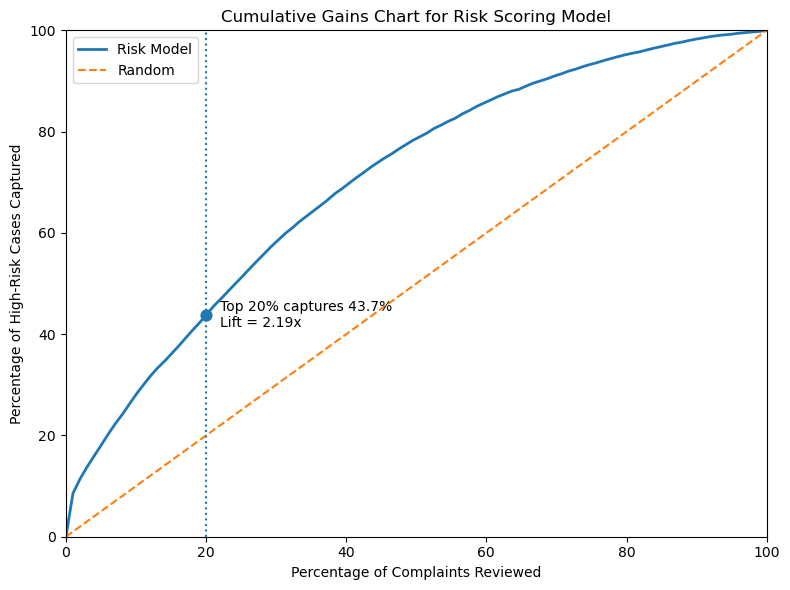

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# INPUTS
# -----------------------------------
# Replace final_val_db with your evaluation dataframe
df = final_val_db.copy()

score_col = "risk_score"
target_col = "high_risk_target"   # 1 = high risk, 0 = not high risk

# -----------------------------------
# SORT BY RISK SCORE (HIGH TO LOW)
# -----------------------------------
gains_df = df[[score_col, target_col]].copy()
gains_df = gains_df.sort_values(score_col, ascending=False).reset_index(drop=True)

# -----------------------------------
# CUMULATIVE % OF POPULATION
# -----------------------------------
gains_df["cum_population"] = np.arange(1, len(gains_df) + 1)
gains_df["cum_population_pct"] = gains_df["cum_population"] / len(gains_df)

# -----------------------------------
# CUMULATIVE % OF POSITIVES CAPTURED
# -----------------------------------
total_positives = gains_df[target_col].sum()

if total_positives == 0:
    raise ValueError("No positive cases found in high_risk_target. Gains chart cannot be computed.")

gains_df["cum_positives"] = gains_df[target_col].cumsum()
gains_df["cum_capture_pct"] = gains_df["cum_positives"] / total_positives

# -----------------------------------
# OPTIONAL: SAMPLE POINTS FOR SMOOTHER PLOT
# -----------------------------------
# Use 100 evenly spaced points to keep chart light
plot_df = gains_df.iloc[np.linspace(0, len(gains_df) - 1, 100).astype(int)].copy()

# Make sure final point is included
plot_df = pd.concat([plot_df, gains_df.iloc[[-1]]], ignore_index=True).drop_duplicates(subset="cum_population_pct")

# -----------------------------------
# COMPUTE TOP 20% CAPTURE
# -----------------------------------
top_pct = 0.20
top_n = int(np.ceil(len(gains_df) * top_pct))
top_capture = gains_df.iloc[:top_n][target_col].sum() / total_positives

# Random baseline capture at 20% = 20%
random_capture = top_pct

# Lift at top 20%
lift_at_20 = top_capture / random_capture

print(f"Total rows: {len(gains_df):,}")
print(f"Total high-risk cases: {int(total_positives):,}")
print(f"Capture in top 20%: {top_capture:.4f} ({top_capture*100:.2f}%)")
print(f"Lift @ top 20%: {lift_at_20:.2f}x")

# -----------------------------------
# PLOT GAINS CHART
# -----------------------------------
plt.figure(figsize=(8, 6))

# Model gains
plt.plot(
    plot_df["cum_population_pct"] * 100,
    plot_df["cum_capture_pct"] * 100,
    linewidth=2,
    label="Risk Model"
)

# Random baseline
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=1.5,
    label="Random"
)

# Vertical line at top 20%
plt.axvline(x=20, linestyle=":", linewidth=1.5)

# Marker for model capture at 20%
plt.scatter(
    [20],
    [top_capture * 100],
    s=60,
    zorder=5
)

# Annotation
plt.text(
    22,
    top_capture * 100,
    f"Top 20% captures {top_capture*100:.1f}%\nLift = {lift_at_20:.2f}x",
    va="center"
)

plt.title("Cumulative Gains Chart for Risk Scoring Model")
plt.xlabel("Percentage of Complaints Reviewed")
plt.ylabel("Percentage of High-Risk Cases Captured")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

  decile  count  positives  response_rate      lift
0     D1  28889       6489       0.224618  2.807734
1     D2  28889       3616       0.125169  1.564612
2     D3  28889       3364       0.116446  1.455574
3     D4  28888       2567       0.088860  1.110757
4     D5  28889       2111       0.073073  0.913412
5     D6  28889       1701       0.058881  0.736008
6     D7  28888       1194       0.041332  0.516651
7     D8  28889        970       0.033577  0.419711
8     D9  28889        704       0.024369  0.304615
9    D10  28889        395       0.013673  0.170913


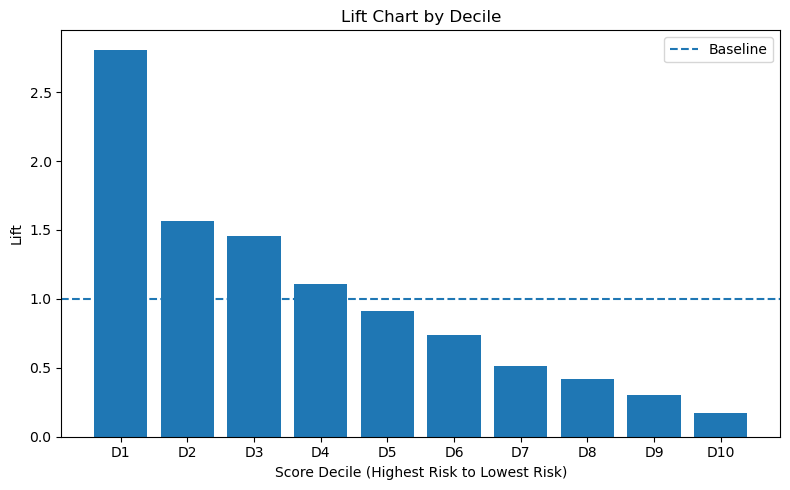

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = final_val_db.copy()

score_col = "risk_score"
target_col = "high_risk_target"

lift_df = df[[score_col, target_col]].copy()
lift_df["decile"] = pd.qcut(
    lift_df[score_col].rank(method="first", ascending=False),
    10,
    labels=[f"D{i}" for i in range(1, 11)]
)

decile_summary = (
    lift_df.groupby("decile", observed=False)[target_col]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positives"})
    .reset_index()
)

decile_summary["response_rate"] = decile_summary["positives"] / decile_summary["count"]
baseline_rate = lift_df[target_col].mean()
decile_summary["lift"] = decile_summary["response_rate"] / baseline_rate

print(decile_summary)

plt.figure(figsize=(8, 5))
plt.bar(decile_summary["decile"], decile_summary["lift"])
plt.axhline(y=1.0, linestyle="--", linewidth=1.5, label="Baseline")
plt.title("Lift Chart by Decile")
plt.xlabel("Score Decile (Highest Risk to Lowest Risk)")
plt.ylabel("Lift")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
final_val_db.info()

In [141]:

context_cols = ["narr_clean", "narr_word_len", "product_bucket", "period"]

df_context = pd.read_parquet("df_llm.parquet", columns=context_cols)

print(df_context.head())
print(df_context.shape)

                                          narr_clean  narr_word_len  \
0  I do not recognize the aforementioned accounts...             54   
1  I am formally disputing inaccurate information...            242   
2  Kindly address this issue on my credit report....             36   
3  I am formally disputing the accuracy of the fo...             60   
4  I am disputing the following inquiries on my E...            101   

     product_bucket      period  
0  Credit Reporting  Post-COVID  
1  Credit Reporting  Post-COVID  
2  Credit Reporting  Post-COVID  
3  Credit Reporting  Post-COVID  
4  Credit Reporting  Post-COVID  
(3095353, 4)


In [142]:
df_context = df_context.drop_duplicates(subset=["narr_clean", "narr_word_len"]).copy()

final_val_db = final_val_db.merge(
    df_context,
    on=["narr_clean", "narr_word_len"],
    how="left"
)

print(final_val_db[["product_bucket", "period"]].head())
print(final_val_db[["product_bucket", "period"]].isna().sum())

         product_bucket      period
0      Credit Reporting       COVID
1                 Cards       COVID
2       Loans & Lending  Post-COVID
3  Credit & Collections       COVID
4      Credit Reporting  Post-COVID
product_bucket    0
period            0
dtype: int64


In [160]:
# =========================================================
# RISK INSIGHTS BY PRODUCT BUCKET AND PERIOD
# =========================================================

# ---------------------------------------------------------
# A. Check that required columns exist
# ---------------------------------------------------------
required_cols = ["risk_bucket", "product_bucket", "period"]
missing_cols = [c for c in required_cols if c not in final_val_db.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are present.")

# ---------------------------------------------------------
# B. Risk distribution overall
# ---------------------------------------------------------
overall_risk_dist = (
    final_val_db["risk_bucket"]
    .value_counts(dropna=False)
    .rename_axis("risk_bucket")
    .reset_index(name="count")
)

overall_risk_dist["percent"] = (
    overall_risk_dist["count"] / overall_risk_dist["count"].sum() * 100
).round(2)

print("\nOverall Risk Distribution")
print(overall_risk_dist)

# ---------------------------------------------------------
# C. High-risk share by product bucket
# ---------------------------------------------------------
product_risk_summary = (
    final_val_db.groupby(["product_bucket", "risk_bucket"])
    .size()
    .unstack(fill_value=0)
)

# make sure all three buckets exist as columns
for col in ["Low Risk", "Medium Risk", "High Risk"]:
    if col not in product_risk_summary.columns:
        product_risk_summary[col] = 0

product_risk_summary["Total"] = product_risk_summary.sum(axis=1)
product_risk_summary["High Risk %"] = (
    product_risk_summary["High Risk"] / product_risk_summary["Total"] * 100
).round(2)

product_risk_summary = product_risk_summary.sort_values(
    by="High Risk %", ascending=False
)

print("\nHigh-Risk Share by Product Bucket")
print(product_risk_summary)

# optional nicer table
product_risk_table = product_risk_summary.reset_index()

# ---------------------------------------------------------
# D. High-risk share by period
# ---------------------------------------------------------
period_risk_summary = (
    final_val_db.groupby(["period", "risk_bucket"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Low Risk", "Medium Risk", "High Risk"]:
    if col not in period_risk_summary.columns:
        period_risk_summary[col] = 0

period_risk_summary["Total"] = period_risk_summary.sum(axis=1)
period_risk_summary["High Risk %"] = (
    period_risk_summary["High Risk"] / period_risk_summary["Total"] * 100
).round(2)

period_risk_summary = period_risk_summary.sort_values(
    by="High Risk %", ascending=False
)

print("\nHigh-Risk Share by Period")
print(period_risk_summary)

period_risk_table = period_risk_summary.reset_index()

# ---------------------------------------------------------
# E. Cross-tab: product bucket x period for only high-risk complaints
# ---------------------------------------------------------
high_risk_only = final_val_db[final_val_db["risk_bucket"] == "High Risk"].copy()

high_risk_product_period = pd.crosstab(
    high_risk_only["product_bucket"],
    high_risk_only["period"],
    margins=True
)

print("\nHigh-Risk Complaints: Product Bucket x Period")
print(high_risk_product_period)

# ---------------------------------------------------------
# F. Most common final failure types within high-risk bucket
# ---------------------------------------------------------
high_risk_failure_summary = (
    high_risk_only["final_pred"]
    .value_counts(dropna=False)
    .rename_axis("final_pred")
    .reset_index(name="count")
)

high_risk_failure_summary["percent"] = (
    high_risk_failure_summary["count"] / high_risk_failure_summary["count"].sum() * 100
).round(2)

print("\nFailure Types Within High-Risk Complaints")
print(high_risk_failure_summary)

# ---------------------------------------------------------
# G. Save outputs
# ---------------------------------------------------------
# overall_risk_dist.to_csv("overall_risk_distribution.csv", index=False)
# product_risk_table.to_csv("high_risk_by_product_bucket.csv", index=False)
# period_risk_table.to_csv("high_risk_by_period.csv", index=False)
# high_risk_product_period.to_csv("high_risk_product_period_crosstab.csv")
# high_risk_failure_summary.to_csv("high_risk_failure_type_distribution.csv", index=False)

# print("\nSaved:")
# print("- overall_risk_distribution.csv")
# print("- high_risk_by_product_bucket.csv")
# print("- high_risk_by_period.csv")
# print("- high_risk_product_period_crosstab.csv")
# print("- high_risk_failure_type_distribution.csv")

All required columns are present.

Overall Risk Distribution
   risk_bucket   count  percent
0     Low Risk  144314    49.95
1  Medium Risk   86793    30.04
2    High Risk   57781    20.00

High-Risk Share by Product Bucket
risk_bucket           High Risk  Low Risk  Medium Risk   Total  High Risk %
product_bucket                                                             
Loans & Lending            6406     11920         9047   27373        23.40
Cards                      5289     11535         7579   24403        21.67
Credit Reporting          33012     82419        50798  166229        19.86
Banking & Payments         6100     16994         9048   32142        18.98
Credit & Collections       6974     21446        10321   38741        18.00

High-Risk Share by Period
risk_bucket  High Risk  Low Risk  Medium Risk   Total  High Risk %
period                                                            
Post-COVID       45435    106529        66054  218018        20.84
Pre-COVID       

The risk scoring framework identifies approximately 20% of complaints as high risk, enabling targeted prioritization. Analysis shows that Loans & Lending and Cards exhibit the highest concentration of high-risk complaints. Additionally, high-risk cases have increased in the post-COVID period, suggesting a rise in complex or unresolved issues. Credit Reporting emerges as the dominant contributor to high-risk complaints, particularly after COVID. While Product/Process Failure accounts for the largest share of high-risk cases, Communication and Escalation Failures remain critical due to their severity and impact. Overall, the framework effectively integrates severity, uncertainty, and contextual signals to prioritize complaints for intervention.

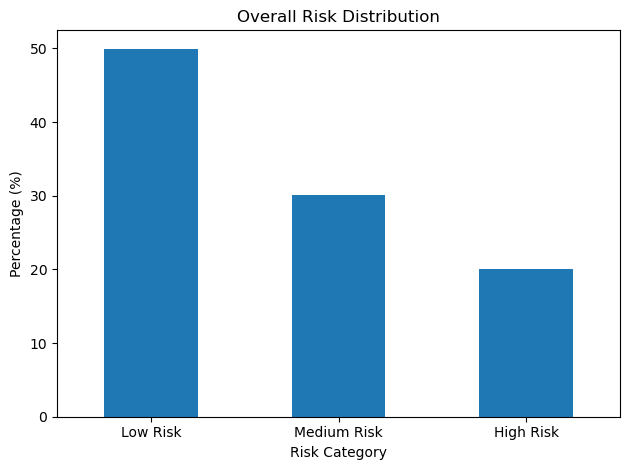

In [163]:
import matplotlib.pyplot as plt

overall_risk_dist.set_index("risk_bucket")["percent"].plot(kind="bar")

plt.title("Overall Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

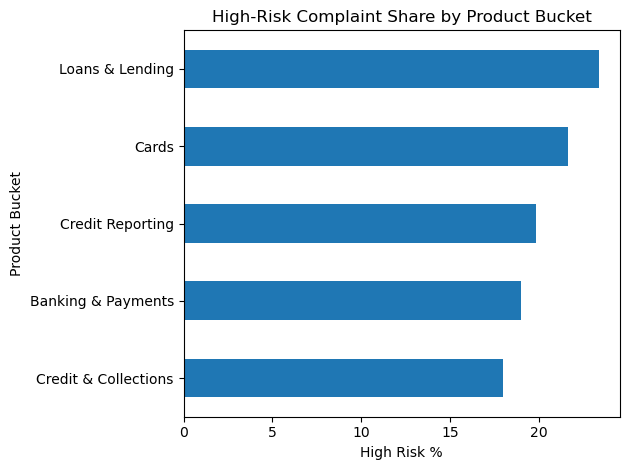

In [165]:
product_risk_summary["High Risk %"].sort_values().plot(kind="barh")

plt.title("High-Risk Complaint Share by Product Bucket")
plt.xlabel("High Risk %")
plt.ylabel("Product Bucket")
plt.tight_layout()
plt.show()

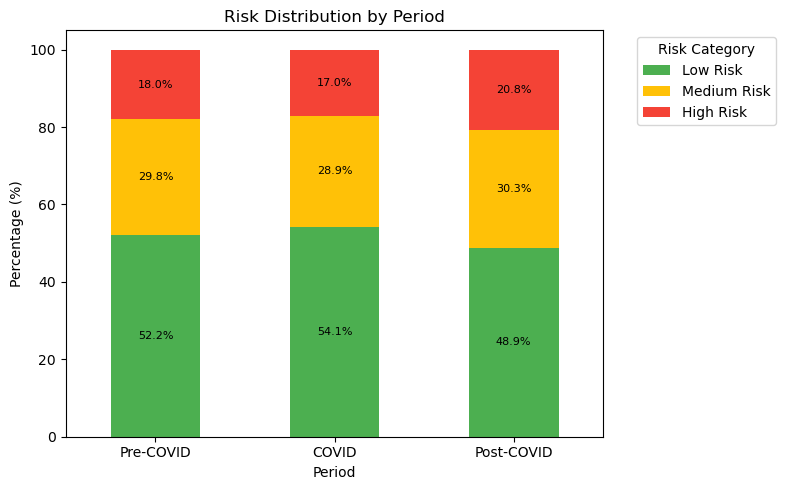

In [169]:
import matplotlib.pyplot as plt

# Create distribution table
period_dist = (
    final_val_db.groupby(["period", "risk_bucket"])
    .size()
    .unstack(fill_value=0)
)

# Ensure correct order of periods
period_order = ["Pre-COVID", "COVID", "Post-COVID"]
period_dist = period_dist.reindex(period_order)

# Convert to percentage
period_dist_pct = period_dist.div(period_dist.sum(axis=1), axis=0) * 100

# Plot
ax = period_dist_pct[["Low Risk", "Medium Risk", "High Risk"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#4CAF50", "#FFC107", "#F44336"]
)

# Add percentage labels inside bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 3:  # avoid clutter for very small segments
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1f}%",
                ha='center',
                va='center',
                fontsize=8,
                color='black'
            )

# Titles and labels
plt.title("Risk Distribution by Period")
plt.xlabel("Period")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

# Move legend outside
plt.legend(
    title="Risk Category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

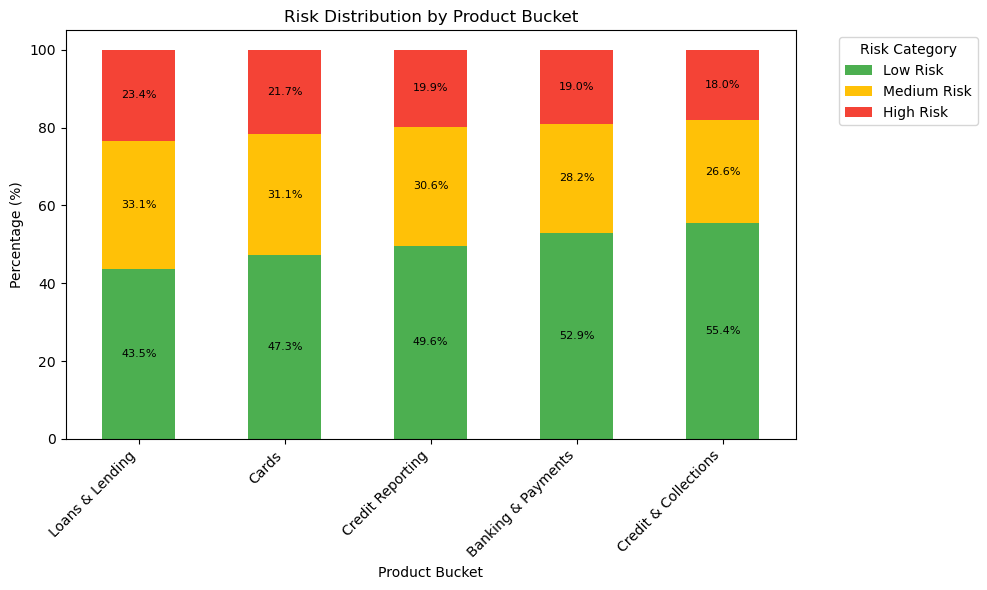

In [171]:
import matplotlib.pyplot as plt

# Create distribution table
product_dist = (
    final_val_db.groupby(["product_bucket", "risk_bucket"])
    .size()
    .unstack(fill_value=0)
)

# Convert to percentage
product_dist_pct = product_dist.div(product_dist.sum(axis=1), axis=0) * 100

# Sort by High Risk %
product_dist_pct = product_dist_pct.sort_values(by="High Risk", ascending=False)

# Plot
ax = product_dist_pct[["Low Risk", "Medium Risk", "High Risk"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#4CAF50", "#FFC107", "#F44336"]
)

# Add percentage labels inside bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 3:  # avoid clutter for very small segments
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1f}%",
                ha='center',
                va='center',
                fontsize=8,
                color='black' if height > 15 else 'white'
            )

# Titles and labels
plt.title("Risk Distribution by Product Bucket")
plt.xlabel("Product Bucket")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha='right')

# Move legend outside
plt.legend(
    title="Risk Category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

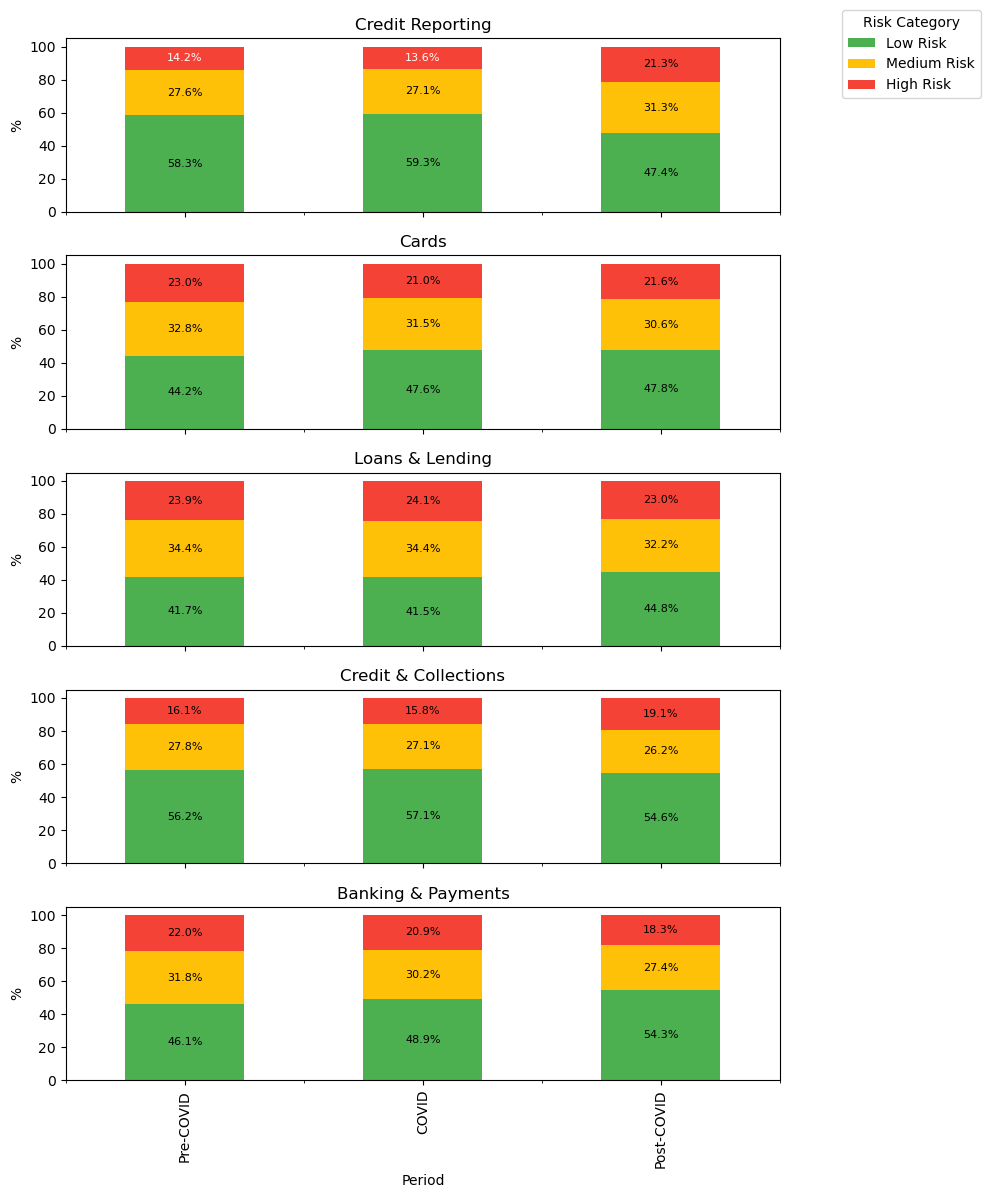

In [177]:
import matplotlib.pyplot as plt

products = final_val_db["product_bucket"].unique()

fig, axes = plt.subplots(len(products), 1, figsize=(8, 12), sharex=True)

for i, product in enumerate(products):
    subset = final_val_db[final_val_db["product_bucket"] == product]
    
    dist = (
        subset.groupby(["period", "risk_bucket"])
        .size()
        .unstack(fill_value=0)
    )
    
    # Ensure correct order
    dist = dist.reindex(["Pre-COVID", "COVID", "Post-COVID"])
    
    # Convert to %
    dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100
    
    ax = dist_pct[["Low Risk", "Medium Risk", "High Risk"]].plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        color=["#4CAF50", "#FFC107", "#F44336"]
    )
    
    # Add labels inside bars
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height > 5:  # avoid clutter
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{height:.1f}%",
                    ha='center',
                    va='center',
                    fontsize=8,
                    color='black' if height > 15 else 'white'
                )
    
    axes[i].set_title(product)
    axes[i].set_ylabel("%")
    axes[i].legend().remove()

# Add one legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Risk Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xlabel("Period")
plt.tight_layout()
plt.show()

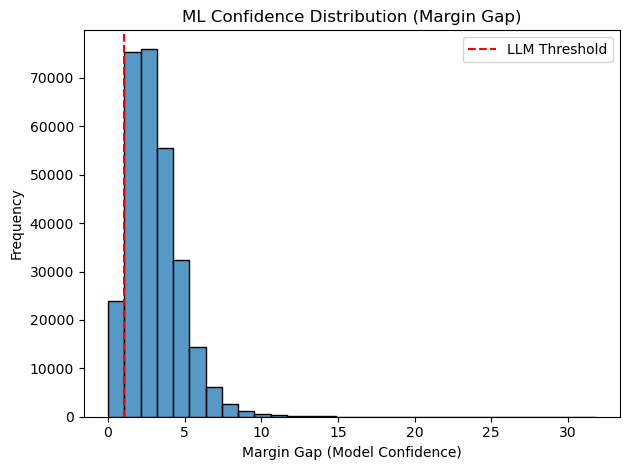

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define threshold (bottom 10%)
threshold = np.percentile(val_df["margin_gap"], 8)

# Plot
sns.histplot(final_val_db["margin_gap"], bins=30)

plt.axvline(threshold, color='red', linestyle='--', label='LLM Threshold')

plt.title("ML Confidence Distribution (Margin Gap)")
plt.xlabel("Margin Gap (Model Confidence)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

Chi-square: 3770.44
p-value: 0.000000
Cramér's V: 0.0808


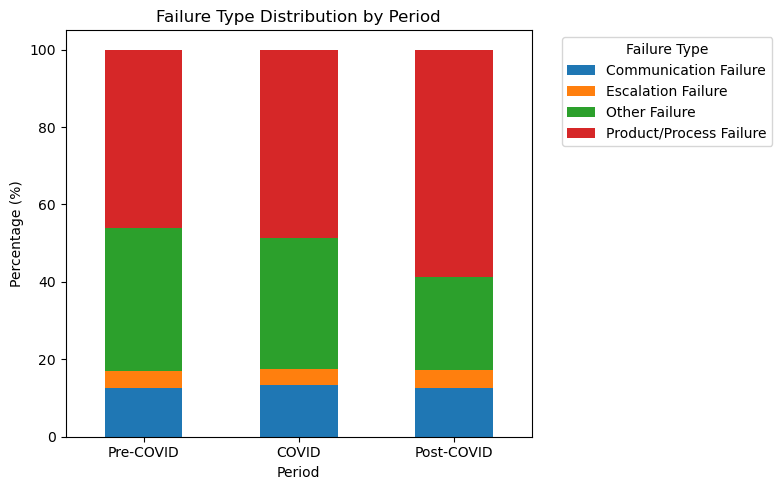

In [187]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# # Merge failure type with period
# analysis = val_df.merge(
#     df_context[["narr_clean", "narr_word_len", "period"]],
#     on=["narr_clean", "narr_word_len"],
#     how="left"
# )

# Chi-square test
ct = pd.crosstab(final_val_db["ml_pred"], final_val_db["period"])
chi2, p, dof, expected = chi2_contingency(ct)

# Cramér's V
n = ct.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.6f}")
print(f"Cramér's V: {cramers_v:.4f}")

# Percent stacked chart
ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
ct_pct = ct_pct[["Pre-COVID", "COVID", "Post-COVID"]]

ax = ct_pct.T.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Failure Type Distribution by Period")
plt.xlabel("Period")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Failure Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [189]:
from sklearn.metrics import cohen_kappa_score

kappa_df = final_val_db.loc[val_df["llm_label"].notna(), ["true_label", "llm_label"]].copy()

# make sure both are plain strings
kappa_df["true_label"] = kappa_df["true_label"].astype(str)
kappa_df["llm_label"] = kappa_df["llm_label"].astype(str)

print("Rows used for Kappa:", len(kappa_df))

kappa = cohen_kappa_score(kappa_df["true_label"], kappa_df["llm_label"])
print("Cohen's Kappa:", round(kappa, 4))

Rows used for Kappa: 28889
Cohen's Kappa: 0.0706


In [197]:
from sklearn.metrics import cohen_kappa_score

# real_ids = [1990948, 1225279, 595664, 755274, 2557683, 928293, 221217, 1390554, 1019961, 223875]

kappa_df = final_val_db[["true_label", "llm_label"]].copy()


kappa_df = kappa_df.dropna()

kappa_df["true_label"] = kappa_df["true_label"].astype(str)
kappa_df["llm_label"] = kappa_df["llm_label"].astype(str)

print(kappa_df)
print("Rows used for Kappa:", len(kappa_df))

kappa = cohen_kappa_score(kappa_df["true_label"], kappa_df["llm_label"])
print("Cohen's Kappa:", round(kappa, 4))

                     true_label                llm_label
24        Communication Failure    Communication Failure
34                Other Failure       Escalation Failure
38                Other Failure       Escalation Failure
40                Other Failure  Product/Process Failure
69        Communication Failure       Escalation Failure
...                         ...                      ...
288818  Product/Process Failure    Communication Failure
288825  Product/Process Failure  Product/Process Failure
288861  Product/Process Failure       Escalation Failure
288870  Product/Process Failure  Product/Process Failure
288871  Product/Process Failure    Communication Failure

[23041 rows x 2 columns]
Rows used for Kappa: 23041
Cohen's Kappa: 0.0836
